<a href="https://colab.research.google.com/github/AliRaddman/ai-bootcamp-DeepLearning/blob/main/notebooks/nlp/03_nlp_baseline_sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div dir="rtl" align="right">

# مدل پایه تحلیل احساس نظرات آمازون

## آماده‌سازی محیط و بررسی داده‌های ورودی

هدف این نوت‌بوک، ساخت یک مدل پایه برای پیش‌بینی امتیاز نظرات کاربران از ۱ تا ۵ است.

در این مرحله فقط ستون‌های ضروری بارگذاری می‌شوند:

- `reviewText_clean`: متن نظر و ورودی مدل
- `overall`: امتیاز واقعی و متغیر هدف
- `row_id`: شناسه نمونه برای ذخیره و ردیابی پیش‌بینی‌ها

بارگذاری‌نکردن ستون‌های غیرضروری باعث کاهش مصرف حافظه می‌شود و تأثیری بر مدل پایه متنی ندارد.

پس از بارگذاری، موارد زیر بررسی می‌شوند:

- ابعاد داده‌ها
- مقادیر گمشده
- کلاس‌های معتبر
- یکتابودن شناسه‌ها
- نبود هم‌پوشانی شناسه و متن میان Train و Validation
- توزیع کلاس‌ها

</div>

In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd


# تنظیم Seed برای بازتولیدپذیری نتایج
SEED = 42
random.seed(SEED)
np.random.seed(SEED)


# مسیر پروژه روی Google Drive برای ذخیره مدل‌ها و خروجی‌ها
PROJECT_ROOT = Path.home() / "GoogleDrive" / "AI_Project2"

# مسیر محلی داده‌ها روی SSD
LOCAL_DATA_DIR = Path.home() / "datasets" / "AI_Project2" / "nlp"

# خروجی‌ها همچنان روی Google Drive تیم ذخیره می‌شوند
NLP_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "nlp"
NLP_MODEL_DIR = PROJECT_ROOT / "models" / "nlp"

# ورودی‌ها از SSD محلی خوانده می‌شوند
train_path = LOCAL_DATA_DIR / "nlp_train_clean.csv"
val_path = LOCAL_DATA_DIR / "nlp_validation_clean.csv"
test_path = LOCAL_DATA_DIR / "nlp_test_clean.csv"

# ایجاد پوشه‌های موردنیاز در صورت نبودن
NLP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
NLP_MODEL_DIR.mkdir(parents=True, exist_ok=True)


# ستون‌های موردنیاز مدل پایه
usecols = [
    "row_id",
    "reviewText_clean",
    "overall",
]


# بررسی اتصال Google Drive و وجود فایل‌ها
assert LOCAL_DATA_DIR.exists(), (
    f"Local data folder not found: {LOCAL_DATA_DIR}"
)

for path in [train_path, val_path]:
    assert path.exists(), f"File not found: {path}"


# بارگذاری داده‌های Train و Validation
train_df = pd.read_csv(
    train_path,
    usecols=usecols,
    dtype={
        "row_id": "int32",
        "overall": "int8",
    },
)

val_df = pd.read_csv(
    val_path,
    usecols=usecols,
    dtype={
        "row_id": "int32",
        "overall": "int8",
    },
)


print("Project root:", PROJECT_ROOT)
print("Train path:", train_path)
print("Validation path:", val_path)
print("Test path:", test_path)

print("\nTrain shape:", train_df.shape)
print("Validation shape:", val_df.shape)


print("\nMissing values:")
print("Train:", train_df.isna().sum().to_dict())
print("Validation:", val_df.isna().sum().to_dict())


print("\nTrain class distribution:")
print(
    train_df["overall"]
    .value_counts(normalize=True)
    .sort_index()
    .round(4)
)

print("\nValidation class distribution:")
print(
    val_df["overall"]
    .value_counts(normalize=True)
    .sort_index()
    .round(4)
)


# بررسی هم‌پوشانی شناسه‌ها
row_id_overlap = len(
    set(train_df["row_id"])
    & set(val_df["row_id"])
)


# بررسی هم‌پوشانی دقیق متن‌ها
train_text_hash = pd.util.hash_pandas_object(
    train_df["reviewText_clean"],
    index=False,
)

val_text_hash = pd.util.hash_pandas_object(
    val_df["reviewText_clean"],
    index=False,
)

text_overlap = len(
    set(train_text_hash)
    & set(val_text_hash)
)


# کنترل‌های نهایی داده‌ها
assert train_df["row_id"].is_unique
assert val_df["row_id"].is_unique

assert row_id_overlap == 0
assert text_overlap == 0

assert set(train_df["overall"].unique()) == {1, 2, 3, 4, 5}
assert set(val_df["overall"].unique()) == {1, 2, 3, 4, 5}


print("\nTrain/Validation row_id overlap:", row_id_overlap)
print("Train/Validation exact text overlap:", text_overlap)
print("\nAll local input checks passed successfully.")

Project root: /home/ali/GoogleDrive/AI_Project2
Train path: /home/ali/datasets/AI_Project2/nlp/nlp_train_clean.csv
Validation path: /home/ali/datasets/AI_Project2/nlp/nlp_validation_clean.csv
Test path: /home/ali/datasets/AI_Project2/nlp/nlp_test_clean.csv

Train shape: (664451, 3)
Validation shape: (166161, 3)

Missing values:
Train: {'row_id': 0, 'overall': 0, 'reviewText_clean': 0}
Validation: {'row_id': 0, 'overall': 0, 'reviewText_clean': 0}

Train class distribution:
overall
1    0.0993
2    0.0675
3    0.0969
4    0.1873
5    0.5491
Name: proportion, dtype: float64

Validation class distribution:
overall
1    0.0980
2    0.0688
3    0.0968
4    0.1849
5    0.5516
Name: proportion, dtype: float64

Train/Validation row_id overlap: 0
Train/Validation exact text overlap: 0

All local input checks passed successfully.


<div dir="rtl" align="right">

## ایجاد مدل‌های مرجع ساده

پیش از ساخت مدل متنی، لازم است عملکرد چند روش بسیار ساده اندازه‌گیری شود. این نتایج به‌عنوان خط مبنا استفاده می‌شوند و مدل اصلی باید به‌طور معناداری از آن‌ها بهتر عمل کند.

دو روش بررسی می‌شوند:

- **Most Frequent:** همیشه پرتکرارترین کلاس، یعنی امتیاز ۵، را پیش‌بینی می‌کند.
- **Stratified:** پیش‌بینی‌ها را به‌صورت تصادفی و متناسب با توزیع کلاس‌های داده آموزش تولید می‌کند.

علاوه بر معیار رسمی `Micro F1`، مقدار `Macro F1` نیز محاسبه می‌شود تا عملکرد مدل روی کلاس‌های کم‌تعداد مشخص شود. در مسئله چندکلاسه تک‌برچسبی، مقدار Micro F1 با Accuracy برابر است.

</div>

In [2]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

X_train_dummy = np.zeros((len(train_df), 1))
X_val_dummy = np.zeros((len(val_df), 1))

y_train = train_df["overall"]
y_val = val_df["overall"]

strategies = {
    "Most Frequent": DummyClassifier(strategy="most_frequent"),
    "Stratified": DummyClassifier(
        strategy="stratified",
        random_state=SEED
    )
}

for name, model in strategies.items():
    model.fit(X_train_dummy, y_train)
    predictions = model.predict(X_val_dummy)

    print(f"\n{name}")
    print("-" * 30)
    print("Accuracy:", round(accuracy_score(y_val, predictions), 4))
    print("Micro F1:", round(f1_score(y_val, predictions, average="micro"), 4))
    print("Macro F1:", round(f1_score(y_val, predictions, average="macro"), 4))


Most Frequent
------------------------------
Accuracy: 0.5516
Micro F1: 0.5516
Macro F1: 0.1422

Stratified
------------------------------
Accuracy: 0.3596
Micro F1: 0.3596
Macro F1: 0.1989


<div dir="rtl" align="right">

## استخراج ویژگی‌های متنی با TF-IDF

مدل‌های کلاسیک نمی‌توانند مستقیماً متن خام را دریافت کنند. بنابراین متن نظرات با روش TF-IDF به بردارهای عددی تبدیل می‌شود.

در این مرحله از ویژگی‌های کلمه‌ای استفاده می‌شود:

- **Unigram:** کلمات منفرد مانند `good`
- **Bigram:** ترکیب دو کلمه مانند `not good`

استفاده از Bigram برای تحلیل احساس اهمیت دارد، زیرا عباراتی مانند `not working` یا `very good` اطلاعات بیشتری از کلمات منفرد دارند.

ویژگی‌ها فقط روی داده Train یاد گرفته می‌شوند و سپس همان تبدیل روی Validation اعمال می‌شود تا از نشت داده جلوگیری شود.

برای کنترل مصرف حافظه، تعداد ویژگی‌ها محدود و نوع داده‌ها `float32` در نظر گرفته شده است.

</div>

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    max_features=150_000,
    sublinear_tf=True,
    dtype=np.float32
)

X_train_tfidf = tfidf.fit_transform(train_df["reviewText_clean"])
X_val_tfidf = tfidf.transform(val_df["reviewText_clean"])

train_density = (
    X_train_tfidf.nnz /
    (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])
)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Vocabulary size:", len(tfidf.vocabulary_))
print("Train non-zero values:", X_train_tfidf.nnz)
print("Matrix density:", f"{train_density:.6%}")
print("TF-IDF dtype:", X_train_tfidf.dtype)

Train TF-IDF shape: (664451, 150000)
Validation TF-IDF shape: (166161, 150000)
Vocabulary size: 150000
Train non-zero values: 97650358
Matrix density: 0.097976%
TF-IDF dtype: float32


<div dir="rtl" align="right">

## آموزش مدل پایه Logistic Regression

در این مرحله یک مدل رگرسیون لجستیک چندکلاسه روی ویژگی‌های TF-IDF آموزش داده می‌شود.

حل‌گر `saga` انتخاب شده است، زیرا از داده‌های Sparse و مسائل چندکلاسه پشتیبانی می‌کند. در اجرای اولیه از وزن‌دهی کلاس‌ها استفاده نمی‌شود تا مدل بر اساس توزیع واقعی داده آموزش ببیند.

معیارهای زیر روی Validation محاسبه می‌شوند:

- `Accuracy` و `Micro F1` برای معیار اصلی پروژه
- `Macro F1` برای بررسی عملکرد روی تمام کلاس‌ها با اهمیت برابر
- `Weighted F1` برای عملکرد کلی با درنظرگرفتن فراوانی کلاس‌ها

گزینه `warm_start` فعال شده است تا در صورت همگرا نشدن مدل بتوان آموزش را بدون شروع کامل از ابتدا ادامه داد.

</div>

In [4]:
import time

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

baseline_lr = LogisticRegression(
    solver="saga",
    C=1.0,
    max_iter=50,
    tol=1e-3,
    class_weight=None,
    warm_start=True,
    random_state=SEED
)

fit_start = time.perf_counter()

baseline_lr.fit(X_train_tfidf, y_train)

fit_time = time.perf_counter() - fit_start

predict_start = time.perf_counter()

val_predictions = baseline_lr.predict(X_val_tfidf)

predict_time = time.perf_counter() - predict_start

print("Training time (seconds):", round(fit_time, 2))
print("Prediction time (seconds):", round(predict_time, 2))
print("Iterations used:", baseline_lr.n_iter_)

print("\nValidation metrics:")
print("Accuracy:", round(accuracy_score(y_val, val_predictions), 4))
print(
    "Micro F1:",
    round(f1_score(y_val, val_predictions, average="micro"), 4)
)
print(
    "Macro F1:",
    round(f1_score(y_val, val_predictions, average="macro"), 4)
)
print(
    "Weighted F1:",
    round(f1_score(y_val, val_predictions, average="weighted"), 4)
)

Training time (seconds): 31.44
Prediction time (seconds): 0.08
Iterations used: [18]

Validation metrics:
Accuracy: 0.7049
Micro F1: 0.7049
Macro F1: 0.535
Weighted F1: 0.6833


<div dir="rtl" align="right">

## ارزیابی عملکرد مدل به تفکیک کلاس‌ها

معیارهای کلی به‌تنهایی مشخص نمی‌کنند مدل روی هر امتیاز چه عملکردی دارد. به همین دلیل، معیارهای زیر برای کلاس‌های ۱ تا ۵ محاسبه می‌شوند:

- **Precision:** چه درصدی از پیش‌بینی‌های یک کلاس درست بوده‌اند.
- **Recall:** چه درصدی از نمونه‌های واقعی آن کلاس پیدا شده‌اند.
- **F1-score:** میانگین متوازن Precision و Recall.
- **Support:** تعداد نمونه‌های واقعی هر کلاس در Validation.

همچنین ماتریس درهم‌ریختگی نرمال‌شده رسم می‌شود تا مشخص شود مدل هر امتیاز را بیشتر با کدام کلاس‌ها اشتباه می‌گیرد.

</div>

Classification report:


,precision,recall,f1-score,support
Rating 1,0.6500,0.7231,0.6846,16276.0
Rating 2,0.4052,0.2170,0.2826,11431.0
Rating 3,0.4428,0.3345,0.3811,16077.0
Rating 4,0.5334,0.4186,0.4691,30719.0
Rating 5,0.8009,0.9235,0.8578,91658.0


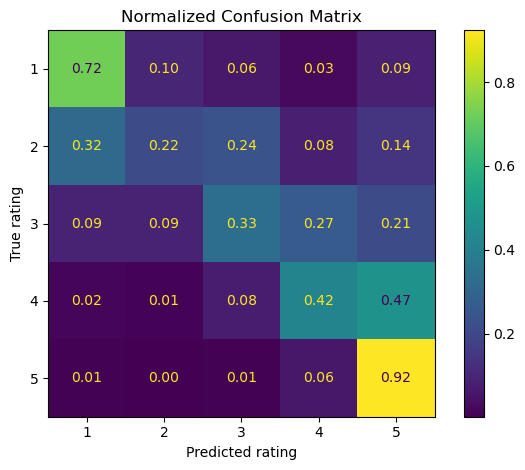

In [5]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay
)

report = classification_report(
    y_val,
    val_predictions,
    labels=[1, 2, 3, 4, 5],
    target_names=["Rating 1", "Rating 2", "Rating 3", "Rating 4", "Rating 5"],
    output_dict=True,
    digits=4
)

report_df = pd.DataFrame(report).T

print("Classification report:")
display(
    report_df.loc[
        ["Rating 1", "Rating 2", "Rating 3", "Rating 4", "Rating 5"],
        ["precision", "recall", "f1-score", "support"]
    ].round(4)
)

ConfusionMatrixDisplay.from_predictions(
    y_val,
    val_predictions,
    labels=[1, 2, 3, 4, 5],
    normalize="true",
    values_format=".2f"
)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted rating")
plt.ylabel("True rating")
plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

## بررسی اثر متوازن‌سازی وزن کلاس‌ها

مدل اولیه روی کلاس‌های ۱ و ۵ عملکرد مناسبی دارد، اما در تشخیص امتیازهای میانی ضعیف‌تر است. یکی از دلایل احتمالی، نامتوازن‌بودن داده و فراوانی زیاد کلاس ۵ است.

برای بررسی این موضوع، یک مدل جدید با تنظیم `class_weight="balanced"` آموزش داده می‌شود. در این روش، کلاس‌های کم‌تعداد وزن بیشتری در تابع خطا دریافت می‌کنند.

تمام تنظیمات دیگر ثابت نگه داشته می‌شوند تا اثر وزن‌دهی کلاس‌ها به‌صورت مستقل بررسی شود. مدل متوازن فقط در صورتی انتخاب می‌شود که بهبود کلاس‌های کم‌تعداد، افت نامناسبی در معیار اصلی پروژه ایجاد نکند.

</div>

In [6]:
from sklearn.metrics import precision_recall_fscore_support

balanced_lr = LogisticRegression(
    solver="saga",
    C=1.0,
    max_iter=50,
    tol=1e-3,
    class_weight="balanced",
    random_state=SEED
)

fit_start = time.perf_counter()
balanced_lr.fit(X_train_tfidf, y_train)
balanced_fit_time = time.perf_counter() - fit_start

balanced_predictions = balanced_lr.predict(X_val_tfidf)

comparison_df = pd.DataFrame(
    {
        "Original": [
            accuracy_score(y_val, val_predictions),
            f1_score(y_val, val_predictions, average="micro"),
            f1_score(y_val, val_predictions, average="macro"),
            f1_score(y_val, val_predictions, average="weighted"),
        ],
        "Balanced": [
            accuracy_score(y_val, balanced_predictions),
            f1_score(y_val, balanced_predictions, average="micro"),
            f1_score(y_val, balanced_predictions, average="macro"),
            f1_score(y_val, balanced_predictions, average="weighted"),
        ],
    },
    index=["Accuracy", "Micro F1", "Macro F1", "Weighted F1"]
)

original_class_f1 = precision_recall_fscore_support(
    y_val,
    val_predictions,
    labels=[1, 2, 3, 4, 5],
    zero_division=0
)[2]

balanced_class_f1 = precision_recall_fscore_support(
    y_val,
    balanced_predictions,
    labels=[1, 2, 3, 4, 5],
    zero_division=0
)[2]

class_f1_df = pd.DataFrame(
    {
        "Original F1": original_class_f1,
        "Balanced F1": balanced_class_f1
    },
    index=[1, 2, 3, 4, 5]
)

print("Training time:", round(balanced_fit_time, 2), "seconds")
print("Iterations used:", balanced_lr.n_iter_)

print("\nOverall metric comparison:")
display(comparison_df.round(4))

print("\nPer-class F1 comparison:")
display(class_f1_df.round(4))

Training time: 87.25 seconds
Iterations used: [50]

Overall metric comparison:


/home/ali/miniconda3/envs/ai-bootcamp/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,Original,Balanced
Accuracy,0.7049,0.6676
Micro F1,0.7049,0.6676
Macro F1,0.5350,0.5259
Weighted F1,0.6833,0.6711



Per-class F1 comparison:


,Original F1,Balanced F1
1,0.6846,0.6549
2,0.2826,0.2193
3,0.3811,0.4298
4,0.4691,0.4929
5,0.8578,0.8324


<div dir="rtl" align="right">

## تنظیم قدرت منظم‌سازی مدل

پس از بررسی وزن‌دهی کلاس‌ها مشخص شد که استفاده از `class_weight="balanced"` باعث کاهش معیارهای کلی و افزایش زمان آموزش می‌شود. بنابراین مدل بدون وزن‌دهی حفظ می‌شود.

در این مرحله اثر پارامتر `C` بررسی می‌شود. این پارامتر شدت Regularization را کنترل می‌کند:

- مقدار کوچک‌تر مانند `0.5` باعث منظم‌سازی قوی‌تر و کاهش احتمال بیش‌برازش می‌شود.
- مقدار بزرگ‌تر مانند `2.0` آزادی بیشتری به مدل برای یادگیری جزئیات داده می‌دهد.
- مقدار `1.0` همان تنظیم مدل اولیه است و به‌عنوان مرجع استفاده می‌شود.

تمام تنظیمات دیگر ثابت باقی می‌مانند تا فقط اثر پارامتر `C` اندازه‌گیری شود. مدل نهایی ابتدا بر اساس `Micro F1` و سپس با توجه به `Macro F1` انتخاب خواهد شد.

</div>

In [7]:
import warnings

from sklearn.exceptions import ConvergenceWarning

c_results = [
    {
        "C": 1.0,
        "Training Time": fit_time,
        "Iterations": int(baseline_lr.n_iter_[0]),
        "Converged": True,
        "Accuracy": accuracy_score(y_val, val_predictions),
        "Micro F1": f1_score(
            y_val, val_predictions, average="micro"
        ),
        "Macro F1": f1_score(
            y_val, val_predictions, average="macro"
        ),
        "Weighted F1": f1_score(
            y_val, val_predictions, average="weighted"
        ),
    }
]

models_by_c = {1.0: baseline_lr}
predictions_by_c = {1.0: val_predictions}

for c_value in [0.5, 2.0]:

    model = LogisticRegression(
        solver="saga",
        C=c_value,
        max_iter=50,
        tol=1e-3,
        class_weight=None,
        random_state=SEED
    )

    with warnings.catch_warnings(record=True) as caught_warnings:
        warnings.simplefilter("always", ConvergenceWarning)

        start_time = time.perf_counter()
        model.fit(X_train_tfidf, y_train)
        training_time = time.perf_counter() - start_time

    predictions = model.predict(X_val_tfidf)

    converged = not any(
        issubclass(warning.category, ConvergenceWarning)
        for warning in caught_warnings
    )

    c_results.append(
        {
            "C": c_value,
            "Training Time": training_time,
            "Iterations": int(model.n_iter_[0]),
            "Converged": converged,
            "Accuracy": accuracy_score(y_val, predictions),
            "Micro F1": f1_score(
                y_val, predictions, average="micro"
            ),
            "Macro F1": f1_score(
                y_val, predictions, average="macro"
            ),
            "Weighted F1": f1_score(
                y_val, predictions, average="weighted"
            ),
        }
    )

    models_by_c[c_value] = model
    predictions_by_c[c_value] = predictions

c_results_df = (
    pd.DataFrame(c_results)
    .sort_values(
        by=["Micro F1", "Macro F1"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(c_results_df.round(4))

,C,Training Time,Iterations,Converged,Accuracy,Micro F1,Macro F1,Weighted F1
0,1.0,31.4388,18,True,0.7049,0.7049,0.5350,0.6833
1,0.5,27.8049,16,True,0.7044,0.7044,0.5273,0.6785
2,2.0,30.8535,18,True,0.7015,0.7015,0.5367,0.6839


<div dir="rtl" align="right">

## بررسی شدت خطاهای مدل

امتیازهای ۱ تا ۵ دارای ترتیب طبیعی هستند. بنابراین Accuracy به‌تنهایی شدت اشتباهات را نشان نمی‌دهد؛ برای مثال، پیش‌بینی امتیاز ۴ به‌جای ۵ با پیش‌بینی امتیاز ۱ به‌جای ۵ یکسان نیست.

در این مرحله معیارهای زیر محاسبه می‌شوند:

- میانگین فاصله مطلق میان امتیاز واقعی و پیش‌بینی‌شده
- درصد پیش‌بینی‌های کاملاً صحیح
- درصد پیش‌بینی‌هایی که حداکثر یک ستاره اختلاف دارند
- درصد خطاهای شدید با اختلاف سه یا چهار ستاره
- پرتکرارترین جفت‌های اشتباه مدل

این تحلیل نشان می‌دهد خطاهای مدل عمدتاً میان کلاس‌های مجاور رخ می‌دهند یا شامل اشتباهات شدید نیز هستند.

</div>

In [9]:
from sklearn.metrics import mean_absolute_error

absolute_errors = np.abs(
    y_val.to_numpy() - val_predictions
)

print(
    "Mean Absolute Error:",
    round(mean_absolute_error(y_val, val_predictions), 4)
)

print(
    "Exact predictions:",
    f"{np.mean(absolute_errors == 0):.2%}"
)

print(
    "Predictions within one star:",
    f"{np.mean(absolute_errors <= 1):.2%}"
)

print(
    "Predictions with two-star error:",
    f"{np.mean(absolute_errors == 2):.2%}"
)

print(
    "Severe errors (3 or 4 stars):",
    f"{np.mean(absolute_errors >= 3):.2%}"
)

error_distance_df = (
    pd.Series(absolute_errors)
    .value_counts()
    .sort_index()
    .rename_axis("Absolute Error")
    .reset_index(name="Count")
)

error_distance_df["Percentage"] = (
    error_distance_df["Count"] / len(y_val) * 100
)

print("\nError-distance distribution:")
display(error_distance_df.round(4))

confusion_pairs_df = pd.DataFrame({
    "True Rating": y_val.to_numpy(),
    "Predicted Rating": val_predictions
})

confusion_pairs_df = (
    confusion_pairs_df[
        confusion_pairs_df["True Rating"]
        != confusion_pairs_df["Predicted Rating"]
    ]
    .value_counts()
    .reset_index(name="Count")
)

confusion_pairs_df["Percentage of All Errors"] = (
    confusion_pairs_df["Count"]
    / confusion_pairs_df["Count"].sum()
    * 100
)

print("\nMost frequent confusion pairs:")
display(confusion_pairs_df.head(10).round(4))

Mean Absolute Error: 0.413
Exact predictions: 70.49%
Predictions within one star: 92.32%
Predictions with two-star error: 4.80%
Severe errors (3 or 4 stars): 2.88%

Error-distance distribution:


,Absolute Error,Count,Percentage
0,0,117129,70.4913
1,1,36266,21.8258
2,2,7975,4.7996
3,3,2750,1.6550
4,4,2041,1.2283



Most frequent confusion pairs:


,True Rating,Predicted Rating,Count,Percentage of All Errors
0,4,5,14579,29.7336
1,5,4,5552,11.3232
2,3,4,4304,8.7779
3,2,1,3676,7.4971
4,3,5,3438,7.0117
5,2,3,2701,5.5086
6,4,3,2357,4.8071
7,1,2,1625,3.3142
8,2,5,1613,3.2897
9,3,1,1485,3.0286


<div dir="rtl" align="right">

## تحلیل کیفی خطاهای شدید

بیشتر پیش‌بینی‌های مدل حداکثر یک ستاره با مقدار واقعی اختلاف دارند. بااین‌حال، حدود ۲.۸۹ درصد از نمونه‌ها دارای اختلاف سه یا چهار ستاره هستند.

در این مرحله نمونه‌های شدیدترین خطاها بررسی می‌شوند. برای هر نمونه موارد زیر نمایش داده می‌شود:

- امتیاز واقعی
- امتیاز پیش‌بینی‌شده
- میزان اختلاف
- اطمینان مدل به پیش‌بینی
- متن نظر

بررسی این نمونه‌ها کمک می‌کند مشخص شود خطاها ناشی از متن‌های مبهم، نظرات چندوجهی، برچسب‌های احتمالی نادرست یا محدودیت مدل TF-IDF هستند.

</div>

In [10]:
val_probabilities = baseline_lr.predict_proba(X_val_tfidf)
prediction_confidence = val_probabilities.max(axis=1)

error_analysis_df = pd.DataFrame({
    "row_id": val_df["row_id"].to_numpy(),
    "reviewText_clean": val_df["reviewText_clean"].to_numpy(),
    "True Rating": y_val.to_numpy(),
    "Predicted Rating": val_predictions,
    "Confidence": prediction_confidence
})

error_analysis_df["Absolute Error"] = np.abs(
    error_analysis_df["True Rating"]
    - error_analysis_df["Predicted Rating"]
)

severe_errors_df = (
    error_analysis_df[
        error_analysis_df["Absolute Error"] >= 3
    ]
    .sort_values(
        by=["Confidence", "Absolute Error"],
        ascending=False
    )
)

print("Number of severe errors:", len(severe_errors_df))

print("\nSevere-error pairs:")
display(
    severe_errors_df[
        ["True Rating", "Predicted Rating"]
    ]
    .value_counts()
    .reset_index(name="Count")
)

print("\nHighest-confidence severe errors:")

with pd.option_context(
    "display.max_colwidth", 250,
    "display.max_rows", 12
):
    display(
        severe_errors_df[
            [
                "row_id",
                "True Rating",
                "Predicted Rating",
                "Absolute Error",
                "Confidence",
                "reviewText_clean"
            ]
        ]
        .head(12)
        .round({"Confidence": 4})
    )

Number of severe errors: 4791

Severe-error pairs:


,True Rating,Predicted Rating,Count
0,2,5,1613
1,1,5,1406
2,5,1,635
3,4,1,542
4,1,4,432
5,5,2,163



Highest-confidence severe errors:


,row_id,True Rating,Predicted Rating,Absolute Error,Confidence,reviewText_clean
114671,573244,1,5,4,0.9883,These are very comfortable and easy to connect to your phone. I have never had a problem with them and I use them daily. They charge quickly and have a decent length of charge. I will eventually be buying these as gifts for christmas as I know ma...
159571,797722,5,1,4,0.9856,"Does nothing for any of my Apple products. Connect it to my iPhone 6s Plus, iPad Pro 12"", iPad Air 2 and thumb drive with photos to load onto said devices and no connection. PLEASE DO NOT WASTE YOUR MONEY ON THIS USELESS DEVICE."
63679,318229,5,1,4,0.9810,I started out liking this product and now I've had it for about 6 months now and it doesn't work properly. It won't recognize when things like USB flash drives are inserted. I bought the power cord separately and that also is a piece of junk :( I...
36247,181160,1,5,4,0.9776,"BEAUTIFUL, WELL-MADE SET. WORKS PERFECTLY ON ALL MY DEVICES. I LOVE THE METAL BODY, SO MUCH MORE SUBSTANTIAL THAN OTHER PLASTIC STYLES. ALSO A BIT LONGER AND HEAVIER, IT FEELS VERY GOOD USING IT. THE EXTRA TIPS ARE A WELCOME BONUS AS THESE WEAR O..."
118473,592257,1,5,4,0.9770,"Very good this works 100% after 10 days NO telemarketers call at all, 3 rings 2 times and the phone hung up. the setup is plug in the included wires to Comcast and have not had to do any more setup. I will order a second one for my business line ..."
107630,538078,2,5,3,0.9733,"Incredible sound and nice color. Waterproof, showered with it. Real bass, balanced sound. Worth every dime! I bought green and light gray. I have many, many Bluetooth speakers ant this is in the top five. I'm very impressed. (Update) I have liste..."
96992,484844,2,5,3,0.9713,WOW! WOW! WOW! The sound is amazing. The metal buds have a rock solid feel to them This is my first week and I love them. Great fit for my ear. Talk all day on my mobile and these are perfect. Snug fit makes for great noise reduction. Well worth ...
131789,658779,4,1,3,0.9711,"ABSOLUTELY TERRIBLE.It drops bluetooth connectivity with my fully updated Android Galaxy S5 about twice a minute. This is the worst connectivity drop ratio I have ever experienced on a bluetooth headset, and that makes this Oduo bluetooth the wor..."
122105,610392,1,5,4,0.9709,I own and have tried a lot of different headphones and for the cost these WONT be beat !! Great build and audiophile sound !! Comes with a bunch of extras in a beautiful package but none of that is what makes these so great ..ITS THE SOUND !! The...
138434,692054,1,5,4,0.9661,"So far I love this tablet. My Samsung galaxy note 10.1 died and I needed a tablet fast because I was going on vacation and needed something to watch movies on the plane,I also do my banking and many there other things I use the tablet for, I hate..."


<div dir="rtl" align="right">

## بررسی نمونه‌های تصادفی از خطاهای شدید

نمونه‌های قبلی بر اساس بیشترین اطمینان مدل انتخاب شده بودند. این روش برای پیدا کردن موارد مشکوک به برچسب‌گذاری نادرست مفید است، اما ممکن است نماینده تمام خطاهای شدید نباشد.

در این مرحله، از هر جفت امتیاز واقعی و پیش‌بینی‌شده چند نمونه به‌صورت تصادفی انتخاب می‌شود. این کار کمک می‌کند دلایل خطاها با سوگیری کمتر بررسی شوند.

دلایل احتمالی شامل موارد زیر هستند:

- ناسازگاری متن با امتیاز ثبت‌شده
- نظرهای چندوجهی شامل نکات مثبت و منفی
- تغییر نظر کاربر در بخش Update
- متن‌های کوتاه یا مبهم
- محدودیت مدل TF-IDF در درک ترتیب و مفهوم جمله

</div>

In [11]:
sampled_severe_errors = (
    severe_errors_df
    .groupby(
        ["True Rating", "Predicted Rating"],
        group_keys=False
    )
    .sample(
        n=3,
        random_state=SEED
    )
    .sort_values(
        ["True Rating", "Predicted Rating"]
    )
)

with pd.option_context(
    "display.max_colwidth", 300,
    "display.max_rows", None
):
    display(
        sampled_severe_errors[
            [
                "row_id",
                "True Rating",
                "Predicted Rating",
                "Confidence",
                "reviewText_clean"
            ]
        ].round({"Confidence": 4})
    )

,row_id,True Rating,Predicted Rating,Confidence,reviewText_clean
130173,650702,1,4,0.2375,These are horrible. They are constantly falling out of my ear when I run and even fall out when I am sitting still. I am very dissappointed and wonder who is reviewing these with five stars because they are as far from that as possible. I need to find new headphones that will actually stay in my...
59329,296536,1,4,0.5176,"I may be rating too soon but after 2 hours of use, these are pretty amazing, very loud, clear sound good bass, the vocals are EXCELLENT, the only thing that is annoying is when the voice says maximum volume more than once, the build quality seems pretty good hopefully im still right 6 months fro..."
76557,382652,1,4,0.4180,"Well, I agree with everyone about these drive being refurbished, or maybe even just wiped and sold as new. I am using mine in a budget storage tower with LVM. Everything is working well so far but my SMART monitoring tools have already detected bad sectors. This is rough because on the one hand,..."
83804,418921,1,5,0.3836,"This is now the THIRD screw I've purchased for this damned tripod. They literally unscrew and fall off with basic use. I have never unscrewed these stupid things and yet here I am, searching for a regular tripod because these keep falling off. I love the feature of these tripods/screws but the e..."
1298,6553,1,5,0.5425,"I have used TERK antennas since 1997. This is a least performer out of any I have purchased. I am within 20 air miles of the major stations (Columbia, SC) with direct line of sight, and I get TWO stations!!! Y-feed antenna MUCH better."
133365,666657,1,5,0.5007,"What it will do: * Switch to the last activated HDMI input * Switch inputs when you press the button What it WON'T do (this is the deal killer): * Switch to another active HDMI when the current input becomes in active. The whole point of buying this was to basically have an auto-switch, so that ..."
126833,633994,2,5,0.3903,They work fine but they look ridiculous on. I've had several BT headsets in my life but these make you look like a big dork. I would never be caught wearing them in a gym. If you want to look like a jackass buy these. I'll use them to go running.
117170,585749,2,5,0.3425,"if you are looking for a siren, with different tones, this is a nice, cheap way to get that. If you are looking for a PA system, so you can talk to people outside your car, you will be severely disappointed. The voice is faint and not understandable at all, so it crashes and burns as a PA system..."
87911,439443,2,5,0.5323,1 star compared to Samsung and other more expensive smart watches. Neat gadget for the price. I gave it to my friends 16 year old brother- he was so excited at first and then figured out this didn't make things more convenient like a smat watch should. You can turn it into a phone since it takes...
150047,750132,4,1,0.9635,Update below: Receiver stopped working after very little use. It's a known problem with Onkyo and I figured I would chance it and I'm now paying the price. No sound at all and the network card doesn't work. Second receiver that this has happened to me. Poor quality!


<div dir="rtl" align="right">

## مقایسه Logistic Regression با Linear SVC

پس از تنظیم Logistic Regression، یک مدل `LinearSVC` نیز روی همان ویژگی‌های TF-IDF آموزش داده می‌شود.

این مقایسه منصفانه است، زیرا:

- داده‌های Train و Validation ثابت هستند.
- ویژگی‌های TF-IDF دقیقاً یکسان‌اند.
- وزن‌دهی کلاس‌ها استفاده نمی‌شود.
- هیچ تغییری در پیش‌پردازش متن ایجاد نمی‌شود.

مدل نهایی ابتدا بر اساس `Micro F1` انتخاب می‌شود. در صورت نزدیک‌بودن نتایج، `Macro F1`، شدت خطاها، سرعت و قابلیت تولید احتمال نیز در تصمیم نهایی در نظر گرفته می‌شوند.

</div>

In [12]:
from sklearn.svm import LinearSVC
from sklearn.metrics import precision_recall_fscore_support

linear_svc = LinearSVC(
    C=1.0,
    class_weight=None,
    dual="auto",
    tol=1e-3,
    max_iter=5000,
    random_state=SEED
)

svc_start = time.perf_counter()
linear_svc.fit(X_train_tfidf, y_train)
svc_training_time = time.perf_counter() - svc_start

svc_predict_start = time.perf_counter()
svc_predictions = linear_svc.predict(X_val_tfidf)
svc_prediction_time = time.perf_counter() - svc_predict_start

svc_absolute_errors = np.abs(
    y_val.to_numpy() - svc_predictions
)

model_comparison_df = pd.DataFrame(
    {
        "Logistic Regression": [
            accuracy_score(y_val, val_predictions),
            f1_score(y_val, val_predictions, average="micro"),
            f1_score(y_val, val_predictions, average="macro"),
            f1_score(y_val, val_predictions, average="weighted"),
            mean_absolute_error(y_val, val_predictions),
            np.mean(np.abs(y_val.to_numpy() - val_predictions) <= 1),
            fit_time,
            predict_time
        ],
        "Linear SVC": [
            accuracy_score(y_val, svc_predictions),
            f1_score(y_val, svc_predictions, average="micro"),
            f1_score(y_val, svc_predictions, average="macro"),
            f1_score(y_val, svc_predictions, average="weighted"),
            mean_absolute_error(y_val, svc_predictions),
            np.mean(svc_absolute_errors <= 1),
            svc_training_time,
            svc_prediction_time
        ]
    },
    index=[
        "Accuracy",
        "Micro F1",
        "Macro F1",
        "Weighted F1",
        "MAE",
        "Within One Star",
        "Training Time",
        "Prediction Time"
    ]
)

lr_class_f1 = precision_recall_fscore_support(
    y_val,
    val_predictions,
    labels=[1, 2, 3, 4, 5],
    zero_division=0
)[2]

svc_class_f1 = precision_recall_fscore_support(
    y_val,
    svc_predictions,
    labels=[1, 2, 3, 4, 5],
    zero_division=0
)[2]

class_comparison_df = pd.DataFrame(
    {
        "Logistic Regression F1": lr_class_f1,
        "Linear SVC F1": svc_class_f1
    },
    index=[1, 2, 3, 4, 5]
)

print("Linear SVC iterations:", linear_svc.n_iter_)

print("\nOverall model comparison:")
display(model_comparison_df.round(4))

print("\nPer-class F1 comparison:")
display(class_comparison_df.round(4))

Linear SVC iterations: 26

Overall model comparison:


,Logistic Regression,Linear SVC
Accuracy,0.7049,0.6873
Micro F1,0.7049,0.6873
Macro F1,0.5350,0.5124
Weighted F1,0.6833,0.6676
MAE,0.4130,0.4417
Within One Star,0.9232,0.9142
Training Time,31.4388,189.1582
Prediction Time,0.0760,0.0849



Per-class F1 comparison:


,Logistic Regression F1,Linear SVC F1
1,0.6846,0.6562
2,0.2826,0.2635
3,0.3811,0.3470
4,0.4691,0.4446
5,0.8578,0.8510


<div dir="rtl" align="right">

## ذخیره مدل پایه و خروجی‌های Validation

بر اساس نتایج آزمایش‌ها، مدل Logistic Regression با تنظیم `C=1.0` به‌عنوان مدل نهایی Baseline انتخاب شد.

این مدل نسبت به Linear SVC:

- معیار Micro F1 بالاتری دارد.
- روی تمام کلاس‌ها عملکرد بهتری نشان می‌دهد.
- خطای امتیازی کمتری دارد.
- زمان آموزش و پیش‌بینی کوتاه‌تری دارد.
- امکان محاسبه احتمال و میزان اطمینان پیش‌بینی را فراهم می‌کند.

در این مرحله موارد زیر ذخیره می‌شوند:

- پیش‌بینی‌های Validation برای مقایسه با مدل عمیق
- مدل Logistic Regression
- مبدل TF-IDF
- معیارها و تنظیمات نهایی مدل

فایل‌های حجیم در Google Drive ذخیره می‌شوند و نباید وارد مخزن GitHub شوند.

</div>

In [13]:
import json
import platform

import joblib
import sklearn


# بررسی آماده‌بودن مسیرهای تعریف‌شده در سلول اول
assert PROJECT_ROOT.exists(), (
    f"Google Drive project folder not found: {PROJECT_ROOT}"
)

NLP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
NLP_MODEL_DIR.mkdir(parents=True, exist_ok=True)


# مدل نهایی انتخاب‌شده
final_model = baseline_lr
final_predictions = val_predictions


# احتمال هر کلاس و میزان اطمینان پیش‌بینی نهایی
final_probabilities = final_model.predict_proba(X_val_tfidf)
final_confidence = final_probabilities.max(axis=1)


# فایل استاندارد پیش‌بینی‌های Validation
validation_predictions_df = pd.DataFrame({
    "sample_id": val_df["row_id"].to_numpy(),
    "true_label": y_val.to_numpy(),
    "predicted_label": final_predictions,
})

validation_output_path = (
    NLP_OUTPUT_DIR / "baseline_nlp_validation_predictions.csv"
)

validation_predictions_df.to_csv(
    validation_output_path,
    index=False,
)


# فایل تکمیلی برای تحلیل خطا و Confidence
validation_analysis_df = validation_predictions_df.copy()

validation_analysis_df["confidence"] = final_confidence

validation_analysis_df["absolute_error"] = np.abs(
    validation_analysis_df["true_label"]
    - validation_analysis_df["predicted_label"]
)

analysis_output_path = (
    NLP_OUTPUT_DIR / "baseline_nlp_validation_analysis.csv"
)

validation_analysis_df.to_csv(
    analysis_output_path,
    index=False,
)


# ذخیره مدل و بردارساز TF-IDF
model_path = (
    NLP_MODEL_DIR / "baseline_logistic_regression.joblib"
)

tfidf_path = (
    NLP_MODEL_DIR / "baseline_tfidf_vectorizer.joblib"
)

joblib.dump(final_model, model_path)
joblib.dump(tfidf, tfidf_path)


# ذخیره معیارها، تنظیمات و نسخه محیط
baseline_metadata = {
    "model": "LogisticRegression",
    "solver": "saga",
    "C": 1.0,
    "class_weight": None,
    "tfidf_ngram_range": [1, 2],
    "tfidf_max_features": 150000,
    "validation_samples": int(len(y_val)),
    "accuracy": float(
        accuracy_score(y_val, final_predictions)
    ),
    "micro_f1": float(
        f1_score(
            y_val,
            final_predictions,
            average="micro",
        )
    ),
    "macro_f1": float(
        f1_score(
            y_val,
            final_predictions,
            average="macro",
        )
    ),
    "weighted_f1": float(
        f1_score(
            y_val,
            final_predictions,
            average="weighted",
        )
    ),
    "mae": float(
        mean_absolute_error(
            y_val,
            final_predictions,
        )
    ),
    "within_one_star": float(
        np.mean(
            np.abs(
                y_val.to_numpy()
                - final_predictions
            ) <= 1
        )
    ),
    "seed": SEED,
    "python_version": platform.python_version(),
    "scikit_learn_version": sklearn.__version__,
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
}

metadata_path = (
    NLP_OUTPUT_DIR / "baseline_nlp_metrics.json"
)

with metadata_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        baseline_metadata,
        file,
        indent=4,
        ensure_ascii=False,
    )


# بارگذاری مجدد فایل پیش‌بینی برای کنترل نهایی
loaded_predictions = pd.read_csv(
    validation_output_path
)

assert len(loaded_predictions) == len(val_df)

assert list(loaded_predictions.columns) == [
    "sample_id",
    "true_label",
    "predicted_label",
]

assert loaded_predictions["sample_id"].is_unique

assert (
    loaded_predictions["predicted_label"]
    .between(1, 5)
    .all()
)


# بررسی ایجاد همه فایل‌ها و خالی‌نبودن آن‌ها
saved_paths = [
    validation_output_path,
    analysis_output_path,
    model_path,
    tfidf_path,
    metadata_path,
]

for path in saved_paths:
    assert path.exists(), f"Saved file not found: {path}"
    assert path.stat().st_size > 0, f"Saved file is empty: {path}"


print("Validation prediction file:", validation_output_path)
print("Validation analysis file:", analysis_output_path)
print("Model file:", model_path)
print("TF-IDF file:", tfidf_path)
print("Metrics file:", metadata_path)

print("\nSaved files:")
for path in saved_paths:
    size_mb = path.stat().st_size / (1024 ** 2)
    print(f"- {path.name}: {size_mb:.2f} MB")

print("\nSaved prediction shape:", loaded_predictions.shape)
print(
    "Saved file columns:",
    loaded_predictions.columns.tolist(),
)

print("\nAll baseline artifacts saved successfully.")

Validation prediction file: /home/ali/GoogleDrive/AI_Project2/outputs/nlp/baseline_nlp_validation_predictions.csv
Validation analysis file: /home/ali/GoogleDrive/AI_Project2/outputs/nlp/baseline_nlp_validation_analysis.csv
Model file: /home/ali/GoogleDrive/AI_Project2/models/nlp/baseline_logistic_regression.joblib
TF-IDF file: /home/ali/GoogleDrive/AI_Project2/models/nlp/baseline_tfidf_vectorizer.joblib
Metrics file: /home/ali/GoogleDrive/AI_Project2/outputs/nlp/baseline_nlp_metrics.json

Saved files:
- baseline_nlp_validation_predictions.csv: 1.72 MB
- baseline_nlp_validation_analysis.csv: 3.69 MB
- baseline_logistic_regression.joblib: 2.86 MB
- baseline_tfidf_vectorizer.joblib: 5.15 MB
- baseline_nlp_metrics.json: 0.00 MB

Saved prediction shape: (166161, 3)
Saved file columns: ['sample_id', 'true_label', 'predicted_label']

All baseline artifacts saved successfully.


<div dir="rtl" align="right">

## اعتبارسنجی فایل‌های ذخیره‌شده

ذخیره‌شدن فایل‌ها به‌تنهایی تضمین نمی‌کند که مدل بعداً بدون مشکل قابل استفاده باشد. بنابراین مدل Logistic Regression و مبدل TF-IDF دوباره از Google Drive بارگذاری می‌شوند.

سپس پیش‌بینی مدل بارگذاری‌شده روی بخشی از Validation با پیش‌بینی مدل اصلی مقایسه می‌شود. برابر بودن کامل نتایج نشان می‌دهد فایل‌های ذخیره‌شده سالم و قابل بازتولید هستند.

</div>

In [14]:
# بارگذاری مجدد مدل و بردارساز از Google Drive
loaded_model = joblib.load(model_path)
loaded_tfidf = joblib.load(tfidf_path)

verification_size = 1000


# انتخاب بخشی از متن‌های Validation برای آزمون کامل Pipeline
verification_texts = val_df[
    "reviewText_clean"
].iloc[:verification_size]


# تبدیل متن با TF-IDF بارگذاری‌شده
reloaded_features = loaded_tfidf.transform(
    verification_texts
)


# پیش‌بینی با مدل بارگذاری‌شده
reloaded_predictions = loaded_model.predict(
    reloaded_features
)


# مقایسه با پیش‌بینی‌های اجرای اصلی
predictions_match = np.array_equal(
    reloaded_predictions,
    final_predictions[:verification_size],
)


artifact_paths = {
    "Validation predictions": validation_output_path,
    "Validation analysis": analysis_output_path,
    "Logistic Regression model": model_path,
    "TF-IDF vectorizer": tfidf_path,
    "Metrics": metadata_path,
}


print("Artifact sizes:")

for artifact_name, artifact_path in artifact_paths.items():
    size_mb = artifact_path.stat().st_size / (1024 ** 2)
    print(f"{artifact_name}: {size_mb:.2f} MB")


print("\nVerification feature shape:", reloaded_features.shape)
print("Reloaded model classes:", loaded_model.classes_)
print(
    "Reloaded TF-IDF features:",
    len(loaded_tfidf.vocabulary_),
)
print("Predictions match:", predictions_match)


# کنترل‌های نهایی
assert predictions_match

assert reloaded_features.shape == (
    verification_size,
    150_000,
)

assert len(loaded_tfidf.vocabulary_) == 150_000

assert loaded_model.classes_.tolist() == [
    1,
    2,
    3,
    4,
    5,
]


print(
    "\nAll saved artifacts were reloaded "
    "and verified successfully."
)

Artifact sizes:
Validation predictions: 1.72 MB
Validation analysis: 3.69 MB
Logistic Regression model: 2.86 MB
TF-IDF vectorizer: 5.15 MB
Metrics: 0.00 MB

Verification feature shape: (1000, 150000)
Reloaded model classes: [1 2 3 4 5]
Reloaded TF-IDF features: 150000
Predictions match: True

All saved artifacts were reloaded and verified successfully.


<div dir="rtl" align="right">

## جمع‌بندی نهایی

در این نوت‌بوک یک مدل پایه برای پیش‌بینی امتیاز نظرات کاربران از ۱ تا ۵ ساخته و ارزیابی شد.

ابتدا سلامت داده‌های Train و Validation بررسی شد. هیچ مقدار گمشده‌ای در ستون‌های ضروری وجود نداشت و هم‌پوشانی شناسه یا متن میان دو مجموعه برابر صفر بود؛ بنابراین نشت مستقیم داده مشاهده نشد.

### مدل‌های مرجع

مدل ساده‌ای که همیشه امتیاز ۵ را پیش‌بینی می‌کرد، به نتایج زیر رسید:

- Micro F1: برابر با `0.5516`
- Macro F1: برابر با `0.1422`

مدل Stratified نیز با پیش‌بینی تصادفی بر اساس توزیع کلاس‌های Train به نتایج زیر رسید:

- Micro F1: برابر با `0.3596`
- Macro F1: برابر با `0.1989`

این نتایج به‌عنوان حداقل معیار مقایسه برای مدل اصلی در نظر گرفته شدند.

### استخراج ویژگی‌ها

متن نظرات با روش TF-IDF کلمه‌ای به ویژگی‌های عددی تبدیل شد. تنظیمات اصلی شامل موارد زیر بودند:

- ویژگی‌های Unigram و Bigram
- حداکثر `150,000` ویژگی
- حداقل فراوانی `5`
- حذف ویژگی‌های بسیار پرتکرار با `max_df=0.95`
- وزن‌دهی لگاریتمی فراوانی کلمات
- ذخیره ماتریس به‌صورت Sparse و با نوع `float32`

استفاده از Bigram امکان ثبت عبارت‌هایی مانند `not good` و `very useful` را فراهم کرد.

ماتریس TF-IDF نهایی دارای ابعاد زیر بود:

- Train: برابر با `(664451, 150000)`
- Validation: برابر با `(166161, 150000)`
- چگالی ماتریس Train: حدود `0.098%`

### انتخاب مدل

چند آزمایش کنترل‌شده انجام شد:

- Logistic Regression بدون وزن‌دهی کلاس‌ها
- Logistic Regression با `class_weight="balanced"`
- مقایسه مقادیر مختلف پارامتر `C`
- مقایسه Logistic Regression با Linear SVC

وزن‌دهی متوازن باعث کاهش Micro F1 از `0.7049` به `0.6676` شد و مدل نیز پس از ۵۰ تکرار به همگرایی کامل نرسید.

در آزمایش پارامتر `C`، مقدار `1.0` بهترین Micro F1 را ایجاد کرد.

Linear SVC نیز به Micro F1 برابر با `0.6873` رسید و علاوه بر عملکرد ضعیف‌تر، زمان آموزش آن حدود `189.16` ثانیه بود؛ درحالی‌که Logistic Regression در حدود `31.44` ثانیه آموزش دید.

در نهایت مدل زیر انتخاب شد:

- مدل: Logistic Regression
- حل‌گر: `saga`
- مقدار `C`: برابر با `1.0`
- وزن‌دهی کلاس‌ها: بدون وزن‌دهی
- تعداد تکرار تا همگرایی: `18`

### نتایج Validation

مدل نهایی به نتایج زیر رسید:

- Accuracy: برابر با `0.7049`
- Micro F1: برابر با `0.7049`
- Macro F1: برابر با `0.5350`
- Weighted F1: برابر با `0.6833`
- Mean Absolute Error: برابر با `0.4130`
- پیش‌بینی دقیق: `70.49%`
- پیش‌بینی صحیح یا با حداکثر یک ستاره اختلاف: `92.32%`
- خطاهای شدید سه یا چهار ستاره‌ای: `2.88%`

مدل نسبت به Most Frequent Dummy Baseline حدود `15.33` واحد درصد بهبود در Micro F1 ایجاد کرد.

بهترین عملکرد مدل مربوط به امتیازهای ۱ و ۵ بود:

- F1 امتیاز ۱: برابر با `0.6846`
- F1 امتیاز ۵: برابر با `0.8578`

تشخیص امتیازهای میانی، به‌ویژه امتیاز ۲، دشوارتر بود. رایج‌ترین اشتباه مدل، پیش‌بینی امتیاز ۵ برای نظرات دارای امتیاز واقعی ۴ بود که حدود `29.73%` تمام خطاهای مدل را تشکیل داد.

### تحلیل خطاها

تعداد خطاهای شدید مدل برابر با `4,791` نمونه بود. بررسی نمونه‌های این گروه نشان داد که بخشی از خطاها به عوامل زیر مربوط‌اند:

- وجود هم‌زمان عبارات مثبت و منفی در یک نظر
- تغییر نظر کاربر در بخش‌های Update
- وجود جملات مثبت در متن منفی یا برعکس
- ناسازگاری احتمالی متن با امتیاز ثبت‌شده
- محدودیت TF-IDF در درک ترتیب جملات و مفهوم کلی متن

در تعدادی از نمونه‌ها، متن کاملاً مثبت با امتیاز ۱ یا متن کاملاً منفی با امتیاز ۵ ثبت شده بود. این موارد نشان می‌دهند که بخشی از خطاهای مشاهده‌شده احتمالاً ناشی از نویز یا ناسازگاری برچسب‌ها هستند.

این محدودیت‌ها برای یک مدل کلاسیک مبتنی بر Bag-of-Words قابل انتظار هستند و زمینه مناسبی برای مقایسه با مدل‌های عمیق فراهم می‌کنند.

### اجرای محلی و مدیریت فایل‌ها

برای افزایش سرعت اجرای محلی، فایل‌های داده از Google Drive روی SSD سیستم کپی شدند و از مسیر محلی خوانده شدند:

`~/datasets/AI_Project2/nlp`

مدل‌ها و خروجی‌های نهایی همچنان مستقیماً در Google Drive مشترک تیم ذخیره شدند:

- خروجی‌ها: `~/GoogleDrive/AI_Project2/outputs/nlp`
- مدل‌ها: `~/GoogleDrive/AI_Project2/models/nlp`

خواندن داده‌ها از SSD، زمان اجرای سلول بارگذاری را از حدود ۱۳ دقیقه به حدود ۵ ثانیه کاهش داد.

### خروجی‌های ذخیره‌شده

موارد زیر ذخیره شدند:

- `baseline_nlp_validation_predictions.csv`
- `baseline_nlp_validation_analysis.csv`
- `baseline_logistic_regression.joblib`
- `baseline_tfidf_vectorizer.joblib`
- `baseline_nlp_metrics.json`

پس از ذخیره‌سازی، مدل و TF-IDF مجدداً بارگذاری شدند. هزار متن Validation با بردارساز بارگذاری‌شده تبدیل و با مدل بارگذاری‌شده پیش‌بینی شدند. نتایج کاملاً با پیش‌بینی‌های اولیه برابر بودند؛ بنابراین فایل‌های ذخیره‌شده سالم و قابل بازتولید هستند.

</div>